In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

## Estimativa de Rotação Facial: Lógica de Avaliação

O código tem como objetivo estimar a orientação correta de uma imagem de rosto, avaliando cada uma das quatro rotações canônicas: 0°, 90°, 180° e 270°. Para cada uma dessas rotações, a imagem é girada e analisada com base em três critérios principais: **simetria vertical**, **pontuação geométrica baseada em gradientes** e **distribuição de bordas com Canny**.

### Simetria Vertical

A simetria vertical mede o quão semelhantes são as metades esquerda e direita do rosto. Isso é feito dividindo a imagem ao meio verticalmente, espelhando horizontalmente a metade direita (invertendo da direita para a esquerda) e calculando a média da diferença absoluta entre essa metade espelhada e a metade esquerda. Quanto menor essa diferença, maior a simetria. Como rostos na orientação correta tendem a ser mais simétricos verticalmente, essa métrica é usada como **critério principal** para decidir qual rotação é a mais provável.

### Pontuação Geométrica

A pontuação geométrica é baseada na distribuição de bordas (ou seja, detalhes estruturais) ao longo da altura da imagem. Para isso, é calculada a magnitude dos gradientes de intensidade e a imagem é dividida em três regiões horizontais: superior, média e inferior. A pontuação é então calculada como a soma das intensidades médias das regiões superior e inferior menos a média da região central, ou seja, `(média_sup + média_inf) - média_central`. A ideia é que, em rostos corretamente orientados, as regiões superior (olhos) e inferior (boca/queixo) apresentem mais bordas do que a região do meio (testa/nariz). Assim, uma pontuação geométrica mais alta indica uma distribuição estrutural esperada e favorece essa rotação como candidata.

### Canny (Distribuição de Bordas)

O detector de bordas de Canny é utilizado para quantificar onde estão concentradas as bordas mais nítidas da imagem. A imagem é dividida horizontalmente em duas metades — superior e inferior — e calcula-se a densidade de bordas em cada uma. Em imagens de rostos corretamente orientadas, espera-se que a densidade de bordas esteja mais concentrada na metade superior (região dos olhos e sobrancelhas). Quando a densidade está maior na metade inferior, isso pode indicar que a imagem está de cabeça para baixo (180°). Essa métrica é usada como critério auxiliar para desempate entre rotações com simetria similar.

### Processo de Decisão

Para cada imagem, o código avalia todas as rotações possíveis, calcula a simetria, a pontuação geométrica e a densidade de bordas com Canny para cada uma delas e, com base nesses valores, escolhe a rotação mais provável:

1. Seleciona todas as rotações com simetria próxima à melhor (dentro de uma tolerância).
2. Se houver apenas uma rotação com simetria mínima, ela é escolhida.
3. Caso haja empate, a pontuação de Canny é usada como critério de desempate.
4. Persistindo o empate, a pontuação geométrica é considerada.


In [2]:
def rotate_image(image, angle):
    """
    Rotates the image to a fixed angle: 0, 90, 180, or 270 degrees.
    """
    if angle == 0:
        return image
    elif angle == 90:
        return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(image, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)


def vertical_symmetry_score(gray):
    """
    Calculates vertical symmetry by comparing left and mirrored right halves of the image.
    """
    h, w = gray.shape
    mid = w // 2
    left = gray[:, :mid]
    right = gray[:, -mid:]
    if left.shape != right.shape:
        return float('inf')
    flipped_right = cv2.flip(right, 1)
    diff = np.abs(left.astype(np.float32) - flipped_right.astype(np.float32))
    return np.mean(diff)


def canny_symmetry_score(gray, threshold1=100, threshold2=200):
    """
    Compares the density of Canny edges in the upper and lower halves of the image.
    Higher density in the lower half may indicate the face is upside down.
    """
    edges = cv2.Canny(gray, threshold1, threshold2)
    h = edges.shape[0]
    upper_half = edges[:h // 2, :]
    lower_half = edges[h // 2:, :]
    upper_density = np.sum(upper_half > 0) / upper_half.size
    lower_density = np.sum(lower_half > 0) / lower_half.size
    return lower_density - upper_density  # Positive = more edges in lower half


def estimate_rotation_angle(image, symmetry_tol=1e-2):
    """
    Estimates the most likely upright rotation angle of a face using symmetry and Canny edge density.
    """
    candidates = []
    for angle in [0, 90, 180, 270]:
        rotated = rotate_image(image, angle)
        gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
        sym = vertical_symmetry_score(gray)
        canny_sym = canny_symmetry_score(gray)
        candidates.append((angle, rotated, sym, canny_sym))

    # Select based on best symmetry score
    candidates.sort(key=lambda x: x[2])
    best_sym = candidates[0][2]
    top_sym = [c for c in candidates if abs(c[2] - best_sym) <= symmetry_tol]

    if len(top_sym) == 1:
        return top_sym[0][:3]  # angle, rotated_img, sym

    # Refine using canny symmetry score (more edges in bottom half is better)
    top_sym.sort(key=lambda x: -x[3])
    return top_sym[0][:3]


def load_images(base_path):
    """
    Loads all image paths from a directory recursively.
    """
    image_paths = []
    for root, _, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
                image_paths.append(os.path.join(root, f))
    random.shuffle(image_paths)
    return image_paths


def process_images(base_path, max_images=20, for_visualization=False):
    """
    Rotates and analyzes images, storing results and optionally returning a subset for visualization.
    """
    results = []
    for image_path in load_images(base_path):
        image = cv2.imread(image_path)
        if image is None:
            continue

        true_rotation = random.choice([0, 90, 180, 270])
        rotated = rotate_image(image, true_rotation)
        display_rotation = {0: 0, 90: 270, 180: 180, 270: 90}[true_rotation]

        angle, rotated_img, sym = estimate_rotation_angle(rotated)
        canny_score = canny_symmetry_score(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2GRAY))

        results.append((image_path, display_rotation, angle, sym, canny_score, rotated_img))

        if len(results) >= max_images and for_visualization:
            break

    return results if for_visualization else results


def plot_confusion_matrix(y_true, y_pred):
    """
    Plots a labeled confusion matrix of predicted vs. true rotation angles.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 90, 180, 270])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    classes = ['0°', '90°', '180°', '270°']
    plt.xticks(np.arange(4), classes)
    plt.yticks(np.arange(4), classes)
    for i in range(4):
        for j in range(4):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()


def compute_balanced_accuracy(results):
    """
    Computes balanced accuracy for estimated rotations and plots confusion matrix.
    """
    true_labels = [true for _, true, *_ in results]
    pred_labels = [pred for _, _, pred, *_ in results]
    acc = balanced_accuracy_score(true_labels, pred_labels)
    plot_confusion_matrix(true_labels, pred_labels)
    return acc


def plot_results(results):
    """
    Displays image results with symmetry and Canny scores.
    """
    n_cols = 5
    n_rows = (len(results) + n_cols - 1) // n_cols
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for idx, (path, true_rot, est_rot, sym, canny, image) in enumerate(results, 1):
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        name = os.path.basename(path)
        title = (
            f"{name}\nTrue: {true_rot}°, Est: {est_rot}°\n"
            f"Sym: {sym:.2f}, Canny: {canny:.2f}"
        )
        plt.subplot(n_rows, n_cols, idx)
        plt.imshow(rgb)
        plt.title(title, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [3]:
def analyze_and_visualize_image(image_path):
    """
    Displays the rotated versions of the input face image, the Canny edge maps,
    and a bar plot of vertical symmetry scores for each rotation angle (0°, 90°, 180°, 270°).
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    angles = [0, 90, 180, 270]
    rotated_images, canny_edges = [], []
    vertical_symmetries = []

    for angle in angles:
        rotated = rotate_image(image, angle)
        gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

        # Canny edges
        canny = cv2.Canny(gray, threshold1=100, threshold2=200)

        rotated_images.append(rotated)
        canny_edges.append(canny)
        vertical_symmetries.append(vertical_symmetry_score(gray))

    fig, axs = plt.subplots(len(angles), 2, figsize=(10, 4 * len(angles)))

    for i, angle in enumerate(angles):
        axs[i, 0].imshow(cv2.cvtColor(rotated_images[i], cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Rotated {angle}°")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(canny_edges[i], cmap='gray')
        axs[i, 1].set_title(f"Canny Edges {angle}°")
        axs[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Vertical symmetry bar chart
    plt.figure(figsize=(6, 4))
    plt.bar([f"{a}°" for a in angles], vertical_symmetries, color='mediumseagreen')
    plt.title("Vertical Symmetry Score by Rotation Angle")
    plt.xlabel("Rotation Angle")
    plt.ylabel("Avg Absolute Difference\n(Lower = More Symmetric)")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


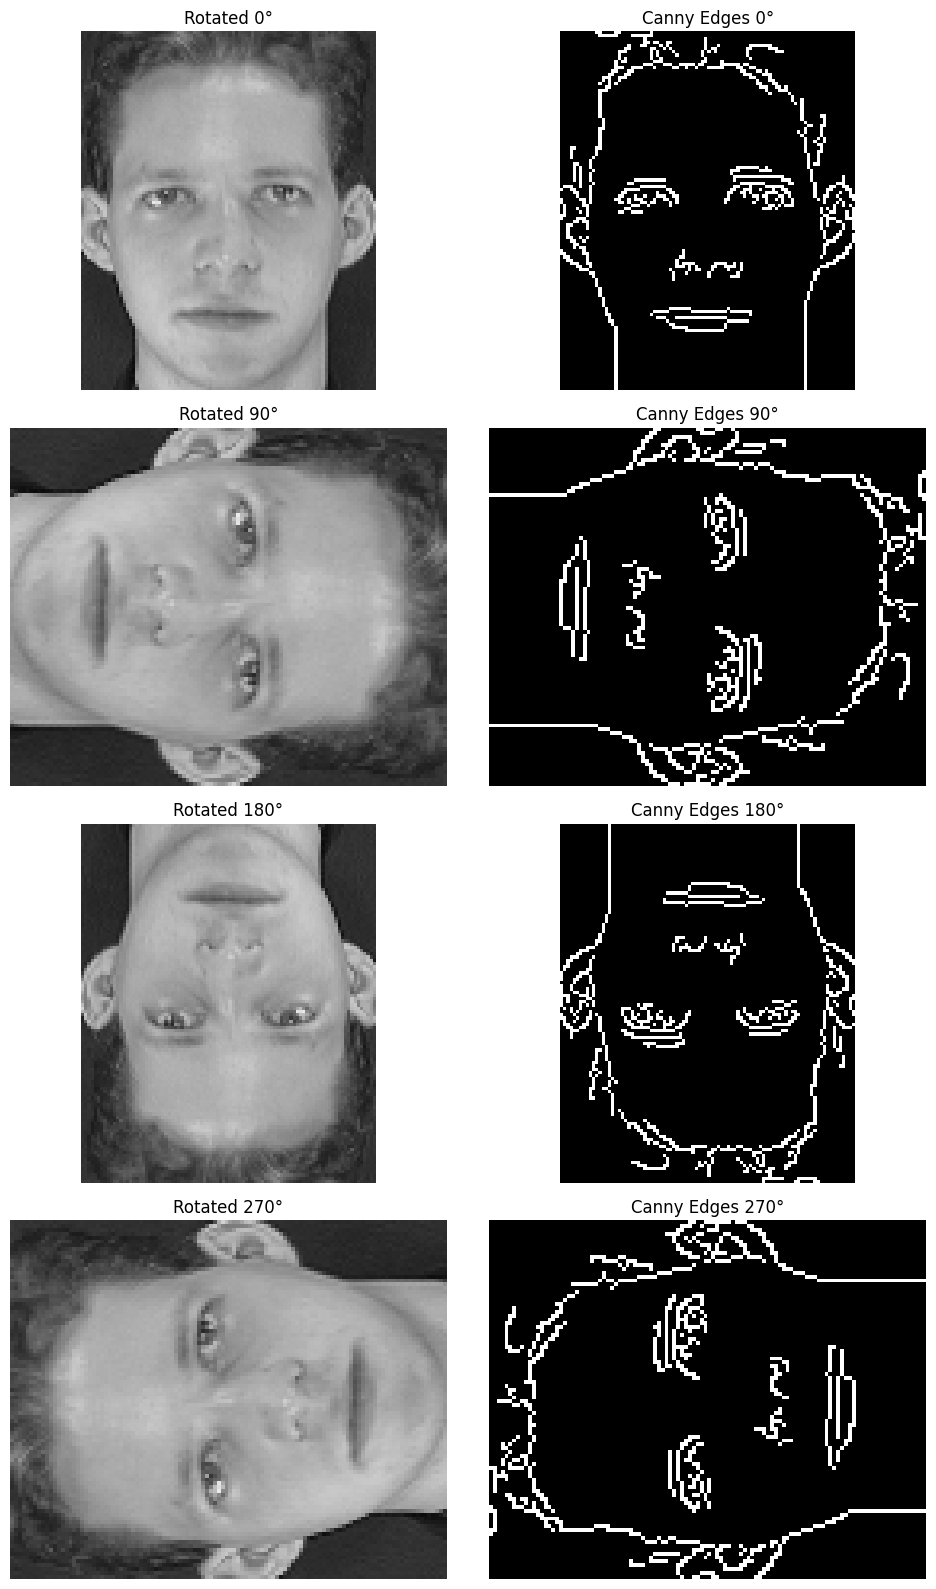

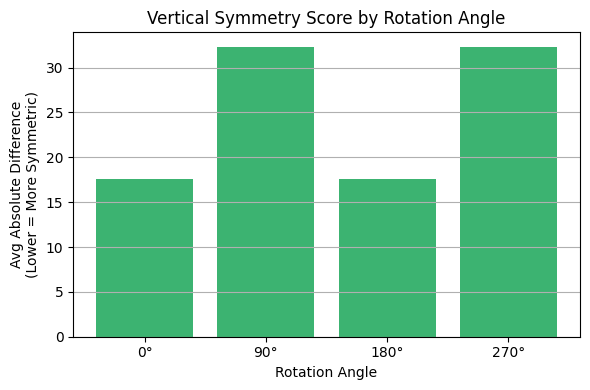

In [4]:
image_path = '../data/s1/1.pgm'
analyze_and_visualize_image(image_path)

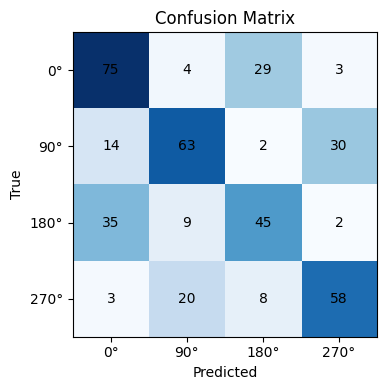

Balanced Accuracy: 0.60


In [5]:
results = process_images("../data/")
acc = compute_balanced_accuracy(results)
print(f"Balanced Accuracy: {acc:.2f}")

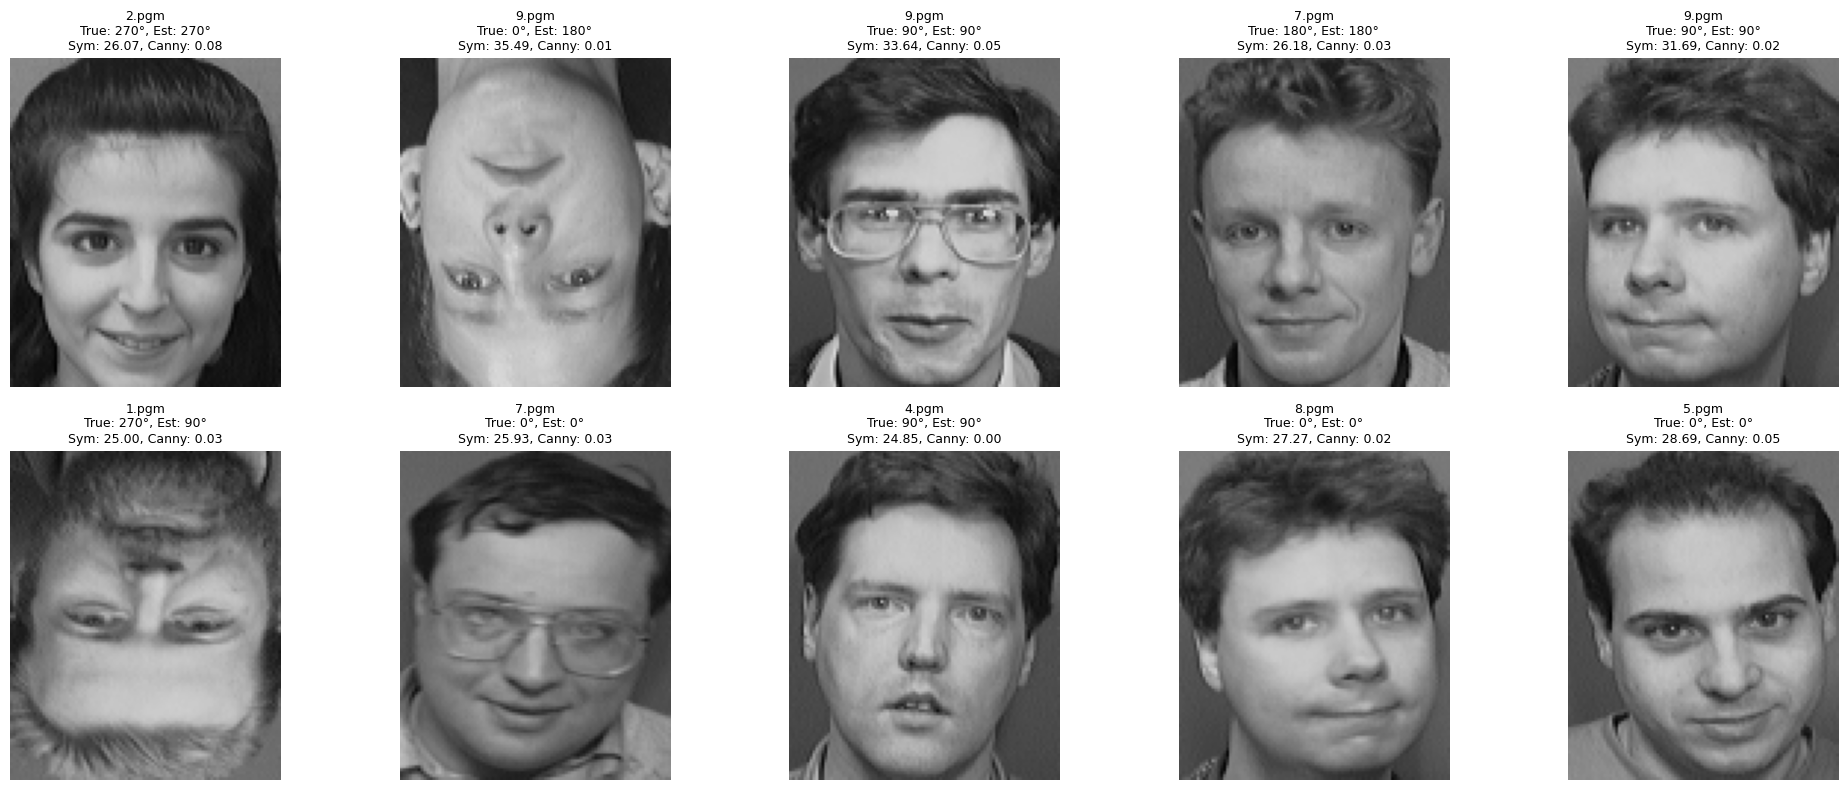

In [6]:
results = process_images("../data/", max_images=10, for_visualization=True)
plot_results(results)